# K-Means Clustering Terminal Bench #


# 1. Importación de Librerias # 

In [ ]:

from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate 
import numpy as np
from sklearn.cluster import KMeans
import plotly.graph_objs as go
import plotly.express as px
%matplotlib inline


C:\Users\LENOVO-PC\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Carga de Datasets 

In [ ]:
# Cargar dataset completo
dataset = load_dataset("ia03/terminal-bench")

# Convertir split test a pandas DataFrame
df = dataset["test"].to_pandas()
df.head()

,task_id,archive,task_yaml,difficulty,tags,author_email,category,base_description,max_agent_timeout_sec,max_test_timeout_sec,tar_sha256,archive_bytes,n_files,generated_at
0,adaptive-rejection-sampler,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed}\x07`...,"# Terminal-Bench Canary String, DO NOT REMOVE:...",medium,"[applied-statistics, adaptive-rejection-sampli...",poulos@berkeley.edu,scientific-computing,Your task is to implement an adaptive-rejectio...,720,300,67bb3bf96df062a37c8158adfb49ca8bd32e45f968d3a4...,15570,7,2025-07-28T16:36:54+00:00
1,aimo-airline-departures,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed=]w\xd...,# BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINI...,hard,"[mathematics, modular-arithmetic, scheduling, ...",wujianbo99999@gmail.com,mathematics,# AIMO Problem 1: Airline Departure Problem\n\...,480,60,c4b50290a096b6bb9f7cd8565ec39d5733b2551680baf3...,5734,6,2025-07-28T16:36:54+00:00
2,attention-mil,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed=\xdbn...,# BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINI...,medium,"[pytorch, attention-mechanism, medical-image-a...",poulos@berkeley.edu,model-training,Complete the missing forward pass implementati...,600,120,9a2c121114e777accad273fbdfe4c06095185782dfa0dc...,8667,9,2025-07-28T16:36:54+00:00
3,blind-maze-explorer-5x5,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed=\xdbv...,# BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINI...,hard,"[maze, exploration, mapping, algorithms]",slimshilin2004@gmail.com,games,You are placed in a blind maze exploration cha...,900,120,49fc2146d00e57951200b457d8c157625fcca6180eaea3...,9425,12,2025-07-28T16:36:54+00:00
4,blind-maze-explorer-algorithm,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed}\xebv...,# BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINI...,medium,"[maze, coding, algorithms]",slimshilin2004@gmail.com,software-engineering,You are placed in a blind maze exploration cha...,900,120,1793ee3acb42213672343ff20bb19bf5c198eb6fa09996...,10415,23,2025-07-28T16:36:54+00:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   task_id                112 non-null    object
 1   archive                112 non-null    object
 2   task_yaml              112 non-null    object
 3   difficulty             112 non-null    object
 4   tags                   112 non-null    object
 5   author_email           112 non-null    object
 6   category               112 non-null    object
 7   base_description       112 non-null    object
 8   max_agent_timeout_sec  112 non-null    int32 
 9   max_test_timeout_sec   112 non-null    int32 
 10  tar_sha256             112 non-null    object
 11  archive_bytes          112 non-null    int64 
 12  n_files                112 non-null    int32 
 13  generated_at           112 non-null    object
dtypes: int32(3), int64(1), object(10)
memory usage: 11.1+ KB


# 3. Selección de Variables para Clustering

Para aplicar K-means de forma adecuada, se seleccionaron únicamente las variables que aportan información cuantitativa y categórica relevante para describir la complejidad, tamaño y naturaleza operativa de las tareas en el dataset. 

Las variables elegidas son:

## Variables categóricas

* **difficulty**
  Nivel de complejidad lógica (fácil, medio, difícil). 

* **category**
  Categoría principal del task. 

## Variables numéricas

* **archive_bytes**
  Tamaño del archivo comprimido asociado a la tarea. 

* **n_files**
  Número de archivos dentro del task. (Indica complejidad).

* **max_agent_timeout_sec**
  Tiempo máximo permitido para ejecución del agente. 

* **max_test_timeout_sec**
  Tiempo máximo para la validación de pruebas. (Indica complejidad operativa).


## - Análisis 2D (Relaciones entre variables Elegidas)

Para estudiar patrones y evaluar si pueden existir agrupaciones naturales antes de aplicar K-means, se utilizarán visualizaciones 2D entre pares de variables.

* **archive_bytes vs n_files**
  Evalúa si tareas más grandes contienen también más archivos.


## 3.1 archive_bites vs n_files ##

In [ ]:
x1 = df.loc[:,['n_files', 'archive_bytes']].values
print(tabulate(x1[:10]))

--  -----
 7  15570
 6   5734
 9   8667
12   9425
23  10415
 8   3485
 8   2002
 9   3435
 9   3448
10   3982
--  -----


### 3.1.1  Variables para Graficas ###

In [ ]:
colors = ['green', 'blue', 'black', 'red', 'pink']
labels_text = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

### 3.1.2 Cluster Metódo del Codo  ###

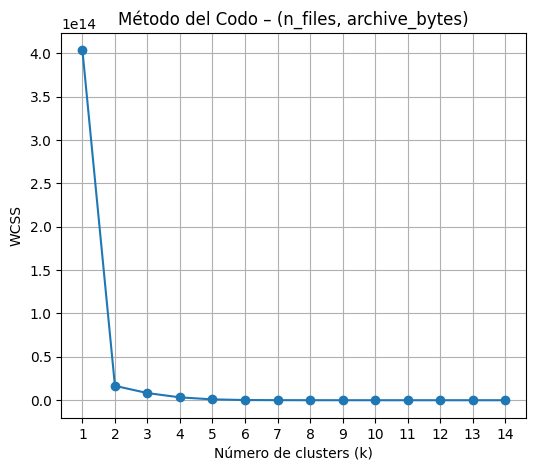

In [ ]:
WCSS_X1 = []

for k in range(1, 15):
    model = KMeans(n_clusters=k, init='k-means++', random_state=0)
    model.fit(x1)
    WCSS_X1.append(model.inertia_)

plt.figure(figsize=(6,5))
plt.plot(range(1,15), WCSS_X1, marker='o')
plt.xticks(range(1,15))
plt.xlabel("Número de clusters (k)")
plt.ylabel("WCSS")
plt.title("Método del Codo – (n_files, archive_bytes)")
plt.grid(True)
plt.show()


### 3.1.3 Aplicar K-Means y visualización 2D ###
Aplicamos K-Means con k=2

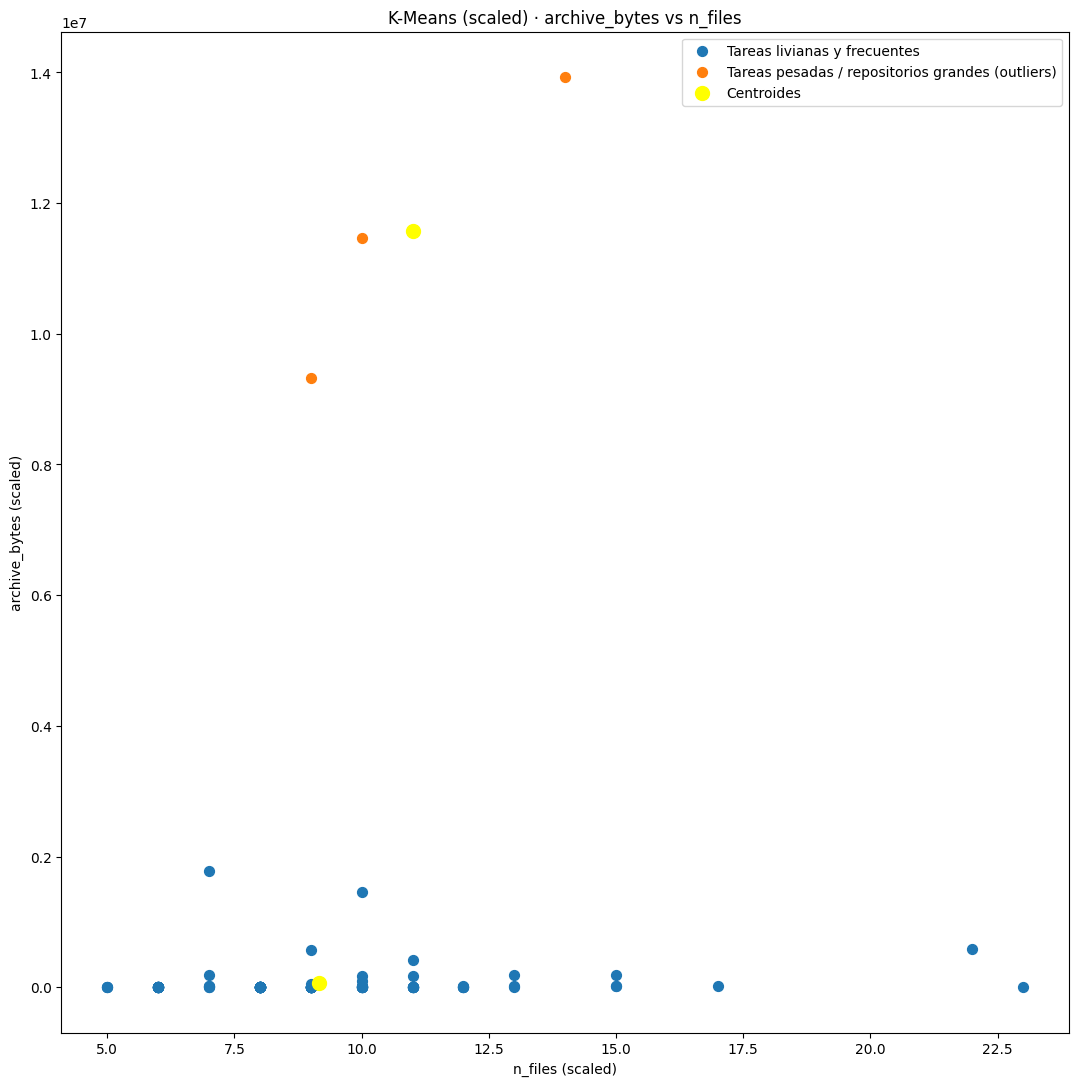

In [ ]:
clusters = 2
model_x1 = KMeans(n_clusters=clusters, init="k-means++", max_iter=300, n_init=10, random_state=0)
y_clusters_x1 = model_x1.fit_predict(x1)

cluster_names = {
    0: "Tareas livianas y frecuentes",
    1: "Tareas pesadas / repositorios grandes (outliers)"
}

plt.figure(figsize=(13,13))

# Dibujar puntos
for i in range(clusters):
    plt.scatter(
        x1[y_clusters_x1 == i, 0],
        x1[y_clusters_x1 == i, 1],
        s=50,
        label=cluster_names[i]
    )

# Dibujar centroides
plt.scatter(
    model_x1.cluster_centers_[:,0],
    model_x1.cluster_centers_[:,1],
    s=100,
    c="yellow",
    label="Centroides"
)

plt.title("K-Means (scaled) · archive_bytes vs n_files")
plt.xlabel("n_files (scaled)")
plt.ylabel("archive_bytes (scaled)")
plt.legend()
plt.show()


## 3.2 ----##

In [ ]:
x_3d = df.loc[:, ['max_agent_timeout_sec', 'max_test_timeout_sec','archive_bytes' ]].values
print(x_3d[:10])

[[  720   300 15570]
 [  480    60  5734]
 [  600   120  8667]
 [  900   120  9425]
 [  900   120 10415]
 [  360    60  3485]
 [  360    60  2002]
 [  360    60  3435]
 [ 1800   600  3448]
 [  360    60  3982]]


### 3.2.1 Aplicar Codo para Clusters  ###


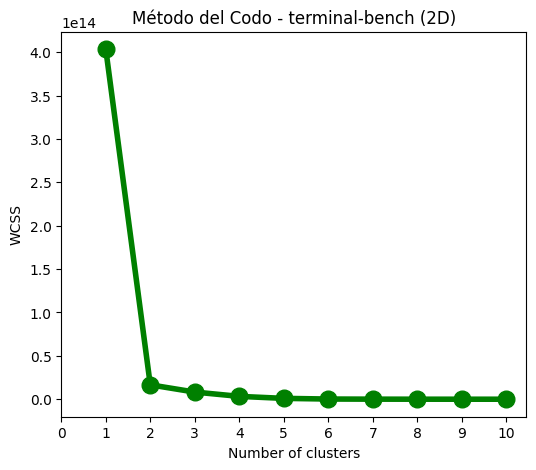

In [ ]:
WCSS_3d = []
for i in range(1,11):
    model_3d = KMeans(n_clusters = i,init = 'k-means++', n_init=10, random_state=42)
    model_3d.fit(x_3d)
    WCSS_3d.append(model_3d.inertia_)

fig = plt.figure(figsize = (6,5))
plt.plot(range(1,11),WCSS_3d, linewidth=4, markersize=12,marker='o',color = 'green')
plt.xticks(np.arange(11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title('Método del Codo - terminal-bench (2D)')
plt.show()

### 3.2.2 Aplicar K-Means y visualización 3D Matplotlib ### 
Aplicamos K-Means con k=4

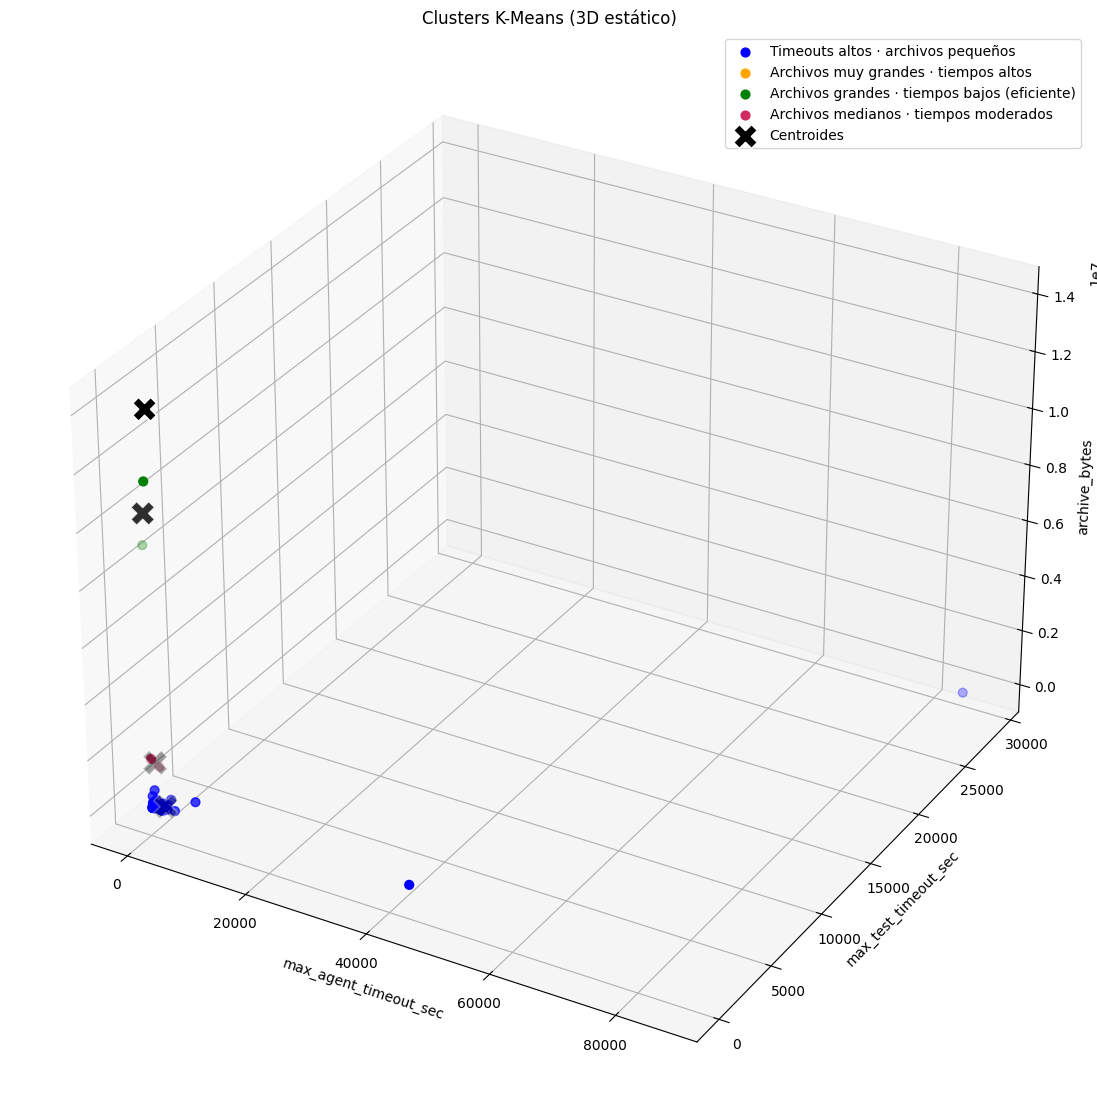

In [ ]:

# K-Means 3D
k_opt= 4
model_3d = KMeans(n_clusters=k_opt, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_clusters_3d = model_3d.fit_predict(x_3d)

fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

colors_3d = ['blue', 'orange', 'green', '#D12B60', 'purple']
labels_3d = [
    "Timeouts altos · archivos pequeños",
    "Archivos muy grandes · tiempos altos",
    "Archivos grandes · tiempos bajos (eficiente)",
    "Archivos medianos · tiempos moderados"
]


# Dibujar puntos por cluster
for i in range(k_opt):
    ax.scatter(
        x_3d[y_clusters_3d == i, 0],x_3d[y_clusters_3d == i, 1],x_3d[y_clusters_3d == i, 2],s=40,color=colors_3d[i],label=labels_3d[i]
    )

ax.scatter(
    model_3d.cluster_centers_[:, 0],model_3d.cluster_centers_[:, 1],model_3d.cluster_centers_[:, 2],s=300,
    marker='X',color='black',edgecolors='white',linewidth=1.2,label='Centroides'
)

ax.set_xlabel('max_agent_timeout_sec')
ax.set_ylabel('max_test_timeout_sec')
ax.set_zlabel('archive_bytes')
ax.set_title('Clusters K-Means (3D estático)')
ax.legend()
plt.show()


plt.show()

In [ ]:
centroides_3d = pd.DataFrame(model_3d.cluster_centers_,
                             columns=['max_agent_timeout_sec','max_test_timeout_sec','archive_bytes'])
print(centroides_3d)


   max_agent_timeout_sec  max_test_timeout_sec  archive_bytes
0            1890.093458            383.457944   2.947333e+04
1            1200.000000            300.000000   1.392840e+07
2             480.000000            150.000000   1.039174e+07
3             780.000000            180.000000   1.617534e+06


### 3.2.2 Aplicar K-Means y visualización 3D Ploty(Interactivo) ### 

In [ ]:
import plotly.graph_objects as go

# Datos y modelo K-Means
# x_3d: tus datos 3D
# model_3d: modelo KMeans ya entrenado

centroids = model_3d.cluster_centers_
labels = model_3d.labels_

# Agregar padding para que no se corten los clusters
padding = 0.05  # 5% sobre el rango
x_min, x_max = x_3d[:,0].min(), x_3d[:,0].max()
y_min, y_max = x_3d[:,1].min(), x_3d[:,1].max()
z_min, z_max = x_3d[:,2].min(), x_3d[:,2].max()

x_range = [x_min - (x_max - x_min)*padding, x_max + (x_max - x_min)*padding]
y_range = [y_min - (y_max - y_min)*padding, y_max + (y_max - y_min)*padding]
z_range = [z_min - (z_max - z_min)*padding, z_max + (z_max - z_min)*padding]

# Scatter de los puntos con tooltip
trace_points = go.Scatter3d(
    x=x_3d[:, 0],
    y=x_3d[:, 1],
    z=x_3d[:, 2],
    mode='markers',
    marker=dict(
        color=labels,
        size=9,
        line=dict(color='black', width=0.5)
    ),
    name='Puntos',
    text=[f'Cluster: {l}<br>x={x:.2f}, y={y:.2f}, z={z:.2f}' 
          for l, x, y, z in zip(labels, x_3d[:,0], x_3d[:,1], x_3d[:,2])],
    hoverinfo='text',
    visible=True  
)

# Scatter de los centroides
trace_centroids = go.Scatter3d(
    x=centroids[:, 0],
    y=centroids[:, 1],
    z=centroids[:, 2],
    mode='markers',
    marker=dict(
        color='black',
        size=7,
        symbol='x',
        line=dict(color='white', width=2)
    ),
    name='Centroides',
    text=[f'Centroide {i}<br>x={x:.2f}, y={y:.2f}, z={z:.2f}' 
          for i, (x,y,z) in enumerate(centroids)],
    hoverinfo='text',
    visible=True
)

# Layout con rangos fijos
layout = go.Layout(
    scene=dict(
        xaxis=dict(title='max_agent_timeout_sec', range=x_range),
        yaxis=dict(title='max_test_timeout_sec', range=y_range),
        zaxis=dict(title='archive_bytes', range=z_range)
    ),
    margin=dict(l=0, r=0),
    height=700,
    width=700,
    title='Clusters K-Means (3D interactivo)'
)

# Crear figura
fig = go.Figure(data=[trace_points, trace_centroids], layout=layout)
fig.show()


## 3.3 ##

In [ ]:

x_3d2 = df.loc[:, ['n_files', 'archive_bytes', 'max_test_timeout_sec' ]].values
print(x_3d2[:10])

[[    7 15570   300]
 [    6  5734    60]
 [    9  8667   120]
 [   12  9425   120]
 [   23 10415   120]
 [    8  3485    60]
 [    8  2002    60]
 [    9  3435    60]
 [    9  3448   600]
 [   10  3982    60]]


### 3.3.1 Aplicar Método Codo para Clusters ### 

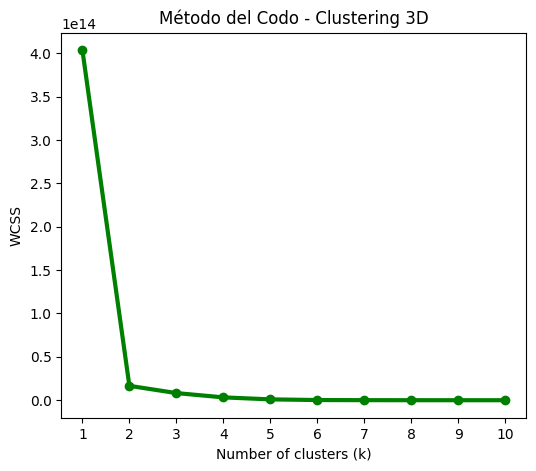

In [ ]:
WCSS_3d2 = []
for i in range(1, 11):
    model_3d2 = KMeans(n_clusters=i, init='k-means++', random_state=0)
    model_3d2.fit(x_3d2)   # x3 es tu matriz 3D
    WCSS_3d2.append(model_3d2.inertia_)

plt.figure(figsize=(6,5))
plt.plot(range(1,11), WCSS_3d2, marker='o', linewidth=3, color='green')
plt.xticks(np.arange(1,11))
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Método del Codo - Clustering 3D")
plt.show()


### 3.3.2 Aplicar K-Means y visualización 3D Matplotlib ### 

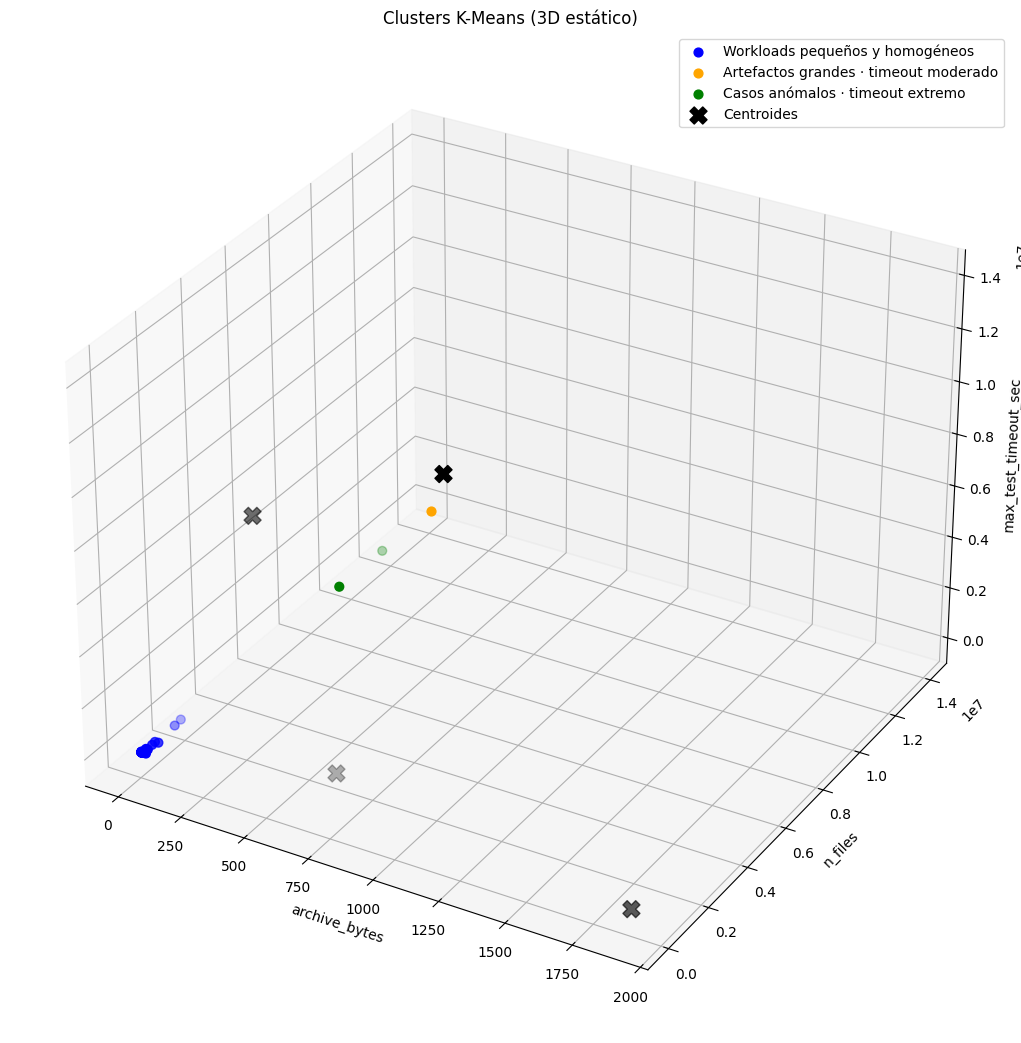

In [ ]:
# K-Means 3D
k_opt2 = 3
model_3d2 = KMeans(n_clusters=k_opt2, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_clusters_3d2 = model_3d2.fit_predict(x_3d2)

# Visualización 3D estática con matplotlib
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

colors_3d2 = ['blue', 'orange', 'green', '#D12B60', 'purple']
labels_3d2 = [
    "Workloads pequeños y homogéneos",
    "Artefactos grandes · timeout moderado",
    "Casos anómalos · timeout extremo"
]

for i in range(k_opt2):
    ax.scatter(x_3d2[y_clusters_3d2 == i, 0], x_3d2[y_clusters_3d2 == i, 1], x_3d2[y_clusters_3d2 == i, 2],
               s=40, color=colors_3d2[i], label=labels_3d2[i])

ax.scatter(centroids[:, 0],centroids[:, 1],centroids[:, 2],
    s=150,          
    color='black', 
    marker='X',    
    label='Centroides'
)
ax.set_xlabel('archive_bytes')
ax.set_ylabel('n_files')
ax.set_zlabel('max_test_timeout_sec')
ax.set_title('Clusters K-Means (3D estático)')
ax.legend()
plt.show()

### 3.2.2 Aplicar K-Means y visualización 3D Ploty (Interactivo) ### 

In [ ]:
# Visualización 3D interactiva con Plotly

labels = model_3d2.labels_
centroids = model_3d2.cluster_centers_

trace_points = go.Scatter3d(x=x_3d2[:, 1],  y=x_3d2[:, 0],  z=x_3d2[:, 2],  
    mode='markers',
    marker=dict(color=labels, size=8, line=dict(color='black', width=1)),
    name='Puntos',
    visible=True  # puedes cambiar a 'legendonly' para ocultar por defecto
)


trace_centroids = go.Scatter3d(
    x=centroids[:, 1],
    y=centroids[:, 0],
    z=centroids[:, 2],
    mode='markers',
    marker=dict(color='black', size=7, symbol='x'),
    name='Centroides',
    visible=True
)

# Layout
scene = dict(
    xaxis=dict(title='n_files'),
    yaxis=dict(title='archive_bytes'),
    zaxis=dict(title='max_agent_timeout_sec')
)

layout = go.Layout(
    scene=scene,
    height=700,
    width=700,
    margin=dict(l=0, r=0),
    title='Clusters K-Means (3D interactivo)'
)


fig = go.Figure(data=[trace_points, trace_centroids], layout=layout)
fig.show()


# 4.  Reestrcutura Transformación de variables categóricas para clustering #

Para preparar el dataset para un modelo de clustering, es necesario transformar todas las variables categóricas en valores numéricos de manera adecuada. En este caso, se aplicaron transformaciones diferentes según la naturaleza de cada columna.



Verificamos lo valores únicos de la columna ``difficulty`` con el fin de hacer una correcta reestructuración

In [ ]:
df['difficulty'].unique()


array(['medium', 'hard', 'easy'], dtype=object)


## 4.1 Transformación de la columna `difficulty` (variable ordinal)

La columna `difficulty` contiene tres niveles como pudimos ver anteriormente con ``df['difficulty'].unique()`` :
```
easy
medium
hard
```

Estos valores representan un **orden natural**, por lo que se transformaron mediante un mapeo ordinal:

```python
df['difficulty'] = df['difficulty'].map({
    'easy': 0,
    'medium': 1,
    'hard': 2
})
```

Esto permite que el modelo interprete correctamente la progresión en los niveles de dificultad.

In [ ]:
df['difficulty'] = df['difficulty'].astype(str).str.strip().str.lower()

df['difficulty'] = df['difficulty'].map({
    'easy': 0,
    'medium': 1,
    'hard': 2,
})

df.head()

,task_id,archive,task_yaml,difficulty,tags,author_email,category,base_description,max_agent_timeout_sec,max_test_timeout_sec,tar_sha256,archive_bytes,n_files,generated_at
0,adaptive-rejection-sampler,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed}\x07`...,"# Terminal-Bench Canary String, DO NOT REMOVE:...",1,"[applied-statistics, adaptive-rejection-sampli...",poulos@berkeley.edu,scientific-computing,Your task is to implement an adaptive-rejectio...,720,300,67bb3bf96df062a37c8158adfb49ca8bd32e45f968d3a4...,15570,7,2025-07-28T16:36:54+00:00
1,aimo-airline-departures,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed=]w\xd...,# BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINI...,2,"[mathematics, modular-arithmetic, scheduling, ...",wujianbo99999@gmail.com,mathematics,# AIMO Problem 1: Airline Departure Problem\n\...,480,60,c4b50290a096b6bb9f7cd8565ec39d5733b2551680baf3...,5734,6,2025-07-28T16:36:54+00:00
2,attention-mil,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed=\xdbn...,# BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINI...,1,"[pytorch, attention-mechanism, medical-image-a...",poulos@berkeley.edu,model-training,Complete the missing forward pass implementati...,600,120,9a2c121114e777accad273fbdfe4c06095185782dfa0dc...,8667,9,2025-07-28T16:36:54+00:00
3,blind-maze-explorer-5x5,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed=\xdbv...,# BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINI...,2,"[maze, exploration, mapping, algorithms]",slimshilin2004@gmail.com,games,You are placed in a blind maze exploration cha...,900,120,49fc2146d00e57951200b457d8c157625fcca6180eaea3...,9425,12,2025-07-28T16:36:54+00:00
4,blind-maze-explorer-algorithm,b'\x1f\x8b\x08\x00&\xa7\x87h\x02\xff\xed}\xebv...,# BENCHMARK DATA SHOULD NEVER APPEAR IN TRAINI...,1,"[maze, coding, algorithms]",slimshilin2004@gmail.com,software-engineering,You are placed in a blind maze exploration cha...,900,120,1793ee3acb42213672343ff20bb19bf5c198eb6fa09996...,10415,23,2025-07-28T16:36:54+00:00


## 4.2 Transformación de la columna `category` (variable nominal)

La columna `category` contiene etiquetas como:

```
scientific-computing, mathematics, debugging, machine-learning, ...
```
Estas categorías **no tienen orden natural**, por lo que no deben convertirse usando un mapeo numérico. En su lugar se aplicó **One-Hot Encoding**:

```python
df = pd.get_dummies(df, columns=['category'])
```
Este proceso genera una columna por cada categoría, con valores binarios (0 o 1) indicando presencia o ausencia.

In [ ]:

df['category'].unique()
# df = pd.get_dummies(df, columns=['category'])

array(['scientific-computing', 'mathematics', 'model-training', 'games',
       'software-engineering', 'system-administration', 'data-science',
       'debugging', 'security', 'file-operations', 'file_operations',
       'personal-assistant', 'machine-learning', 'algorithms'],
      dtype=object)

### 4.2.1 --- ###

In [ ]:
df['category'] = df['category'].replace({
    'file_operations': 'file-operations'
})
df['category'].unique()

array(['scientific-computing', 'mathematics', 'model-training', 'games',
       'software-engineering', 'system-administration', 'data-science',
       'debugging', 'security', 'file-operations', 'personal-assistant',
       'machine-learning', 'algorithms'], dtype=object)

### 4.2.2 --- ###

In [ ]:
df = pd.get_dummies(df, columns=['category'])


## 4.3 Resultado final ##

* `difficulty` → Transformada con **map** por ser una variable **ordinal**.
* `category` → Transformada con **One-Hot Encoding** por ser una variable **nominal**.

De esta forma, todas las columnas quedan correctamente preparadas para algoritmos de clustering como K-Means.


# 5 #

## 5.1 Escalando Variables ##

In [ ]:
from sklearn.preprocessing import StandardScaler
x = df[['difficulty', 'n_files', 'archive_bytes']].values

# x = df[numeric_cols + dummy_cols].values

scaler = StandardScaler()
print(tabulate(x))
x_scaled = scaler.fit_transform(x)


-  --  ----------------
1   7   15570
2   6    5734
1   9    8667
2  12    9425
1  23   10415
1   8    3485
1   8    2002
1   9    3435
1   9    3448
1  10    3982
2   8    4238
2  10       1.46086e+06
2   9    7332
2   6    4608
1   9    6042
1   7    5257
2  11    5772
1  10    3626
2   8    3748
0   8    2081
0   7    3228
1   9    2552
0   8    2346
1   9    4800
2  15   13773
0   9    1932
1   8    4627
1   9  572893
1  10   22927
1   8    2457
1   9    5599
2   8    4298
0   6    2207
2  11    4242
2   9    7694
1   8    2806
1  11    3799
1   9    3715
0   9    1831
2  11    8791
1   6    6840
2   9    3190
0  10    5549
2   8    4299
0   8    2634
0   6    3941
0   8    1599
1  10    2603
1   6    3744
1  11    7479
1   6    2036
2  17   17782
2  22  585153
1   9    5914
0   6    4061
1   8    4459
0   8    9881
2  11  171529
2  10  171145
0   7  189973
0   6    2018
0  11    4715
2  15  182348
1  12    3383
1   6    3899
0   8    6583
2   9    2126
1   8    4420
2  12    5320


### 5.1.2 Cluster Metódo del Codo  ###

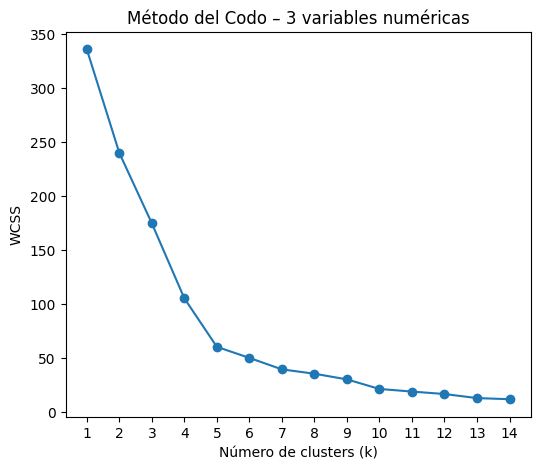

In [ ]:
WCSS = []
for k in range(1, 15):
    model = KMeans(n_clusters=k, init='k-means++', random_state=0)
    model.fit(x_scaled)
    WCSS.append(model.inertia_)

plt.figure(figsize=(6,5))
plt.plot(range(1, 15), WCSS, marker='o')
plt.xticks(range(1, 15))
plt.xlabel("Número de clusters (k)")
plt.ylabel("WCSS")
plt.title("Método del Codo – 3 variables numéricas")
plt.show()


### 5.1.3 Aplicar K-Means y visualización 3D Matplotlib ### 
Aplicamos K-Means con k=5

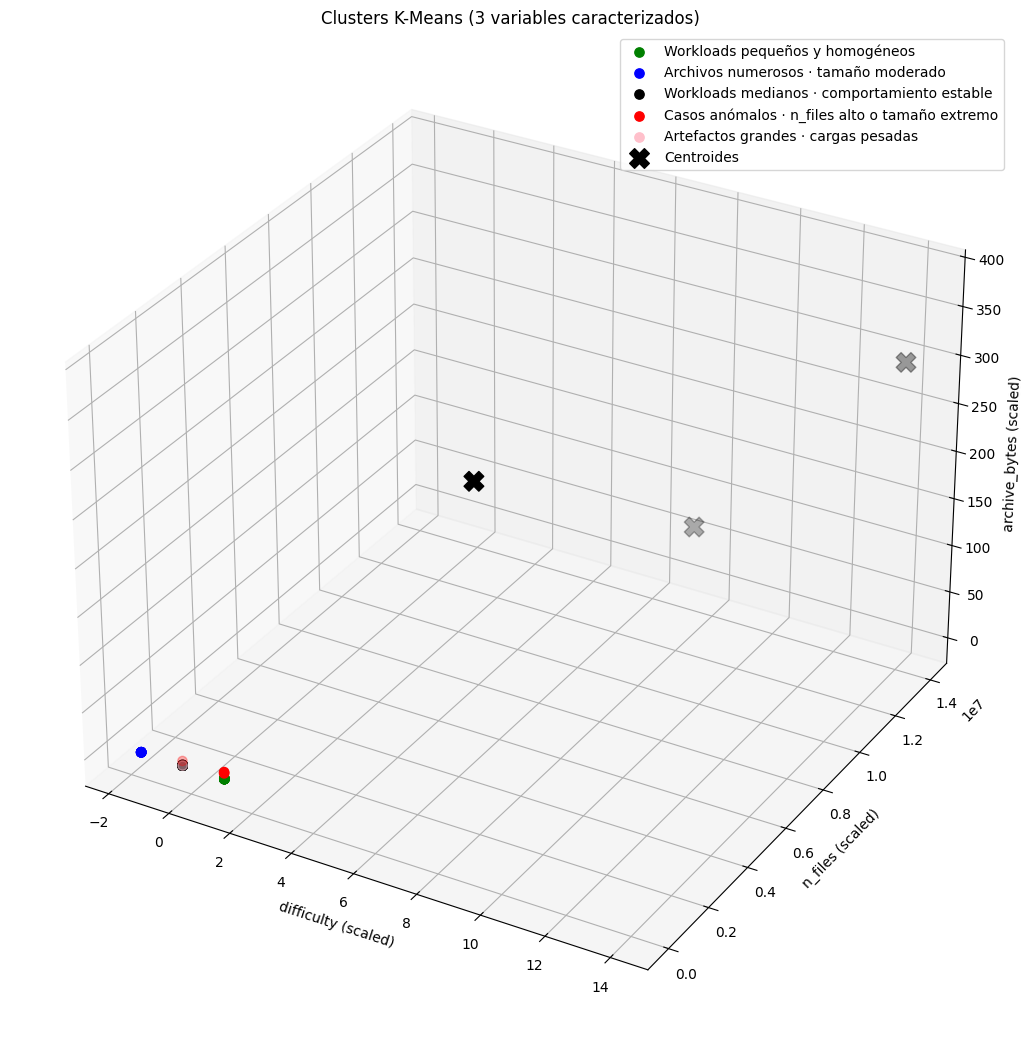

In [ ]:
clusters_opt = 5
model_x = KMeans(n_clusters=clusters_opt, init='k-means++', n_init=10, random_state=42)
y_clusters_x = model_x.fit_predict(x_scaled)

# Visualización 3D usando x_scaled
labels = [
    "Workloads pequeños y homogéneos",
    "Archivos numerosos · tamaño moderado",
    "Workloads medianos · comportamiento estable",
    "Casos anómalos · n_files alto o tamaño extremo",
    "Artefactos grandes · cargas pesadas"
]

labels = labels[:clusters_opt]

# ---------------------------------------------------
# 4. Gráfica 3D caracterizada
# ---------------------------------------------------
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

for i in range(clusters_opt):
    ax.scatter(
        x_scaled[y_clusters_x == i, 0],
        x_scaled[y_clusters_x == i, 1],
        x_scaled[y_clusters_x == i, 2],
        s=45,
        color=colors[i],
        label=labels[i]
    )

# Centroides
ax.scatter(
    centroids[:, 0], centroids[:, 1], centroids[:, 2],
    s=200,
    color='black',
    marker='X',
    label='Centroides'
)

# Etiquetas de ejes
ax.set_xlabel('difficulty (scaled)')
ax.set_ylabel('n_files (scaled)')
ax.set_zlabel('archive_bytes (scaled)')
ax.set_title('Clusters K-Means (3 variables caracterizados)')

ax.legend()
plt.show()


### 5.1.4 Aplicar K-Means y visualización 3D Ploty (interactiva) ### 
Aplicamos K-Means con k=4

In [ ]:
# Colores para los 5 clusters
colors = ['blue', 'orange', 'green', '#D12B60', 'purple']

# Etiquetas de caracterización (EDÍTALAS si deseas)


# Centroides reales del modelo
centroids = model_x.cluster_centers_

fig = go.Figure()

for i in range(clusters_opt):
    fig.add_trace(
        go.Scatter3d(
            x=x_scaled[y_clusters_x == i, 0],
            y=x_scaled[y_clusters_x == i, 1],
            z=x_scaled[y_clusters_x == i, 2],
            mode="markers",
            marker=dict(size=4, color=colors[i]),
            name=labels[i],
            hovertemplate=(
                "<b>Cluster:</b> " + labels[i] + "<br>" +
                "difficulty: %{x:.2f}<br>" +
                "n_files: %{y:.2f}<br>" +
                "archive_bytes: %{z:.2f}<br><extra></extra>"
            )
        )
    )

# Centroides en Plotly
fig.add_trace(
    go.Scatter3d(
        x=centroids[:, 0],
        y=centroids[:, 1],
        z=centroids[:, 2],
        mode="markers",
        marker=dict(size=10, color='black', symbol="x"),
        name="Centroides"
    )
)

fig.update_layout(
    title="Clusters K-Means (difficulty · n_files · archive_bytes) – Visualización 3D Interactiva",
    width=900,
    height=800,
    scene=dict(
        xaxis_title="difficulty (scaled)",
        yaxis_title="n_files (scaled)",
        zaxis_title="archive_bytes (scaled)"
    )
)

fig.show()


## 5.2 Otro análisis 3D ##


In [ ]:
from sklearn.preprocessing import StandardScaler
x2 = df[['difficulty', 'max_agent_timeout_sec', 'max_test_timeout_sec']].values

# x = df[numeric_cols + dummy_cols].values

scaler = StandardScaler()
x2_scaled = scaler.fit_transform(x2)
print(tabulate(x2_scaled))


---------  -----------  -----------
-0.258199  -0.124258    -0.0277312
 1.11886   -0.15091     -0.116577
-0.258199  -0.137584    -0.0943653
 1.11886   -0.104269    -0.0943653
-0.258199  -0.104269    -0.0943653
-0.258199  -0.164236    -0.116577
-0.258199  -0.164236    -0.116577
-0.258199  -0.164236    -0.116577
-0.258199  -0.00432304   0.0833257
-0.258199  -0.164236    -0.116577
 1.11886   -0.164236    -0.116577
 1.11886   -0.0709533   -0.0277312
 1.11886   -0.137584    -0.0943653
 1.11886    9.39055     10.5227
-0.258199  -0.164236    -0.116577
-0.258199  -0.164236    -0.116577
 1.11886   -0.164236    -0.116577
-0.258199  -0.0931635    0.0833257
 1.11886   -0.164236    -0.116577
-1.63526   -0.137584    -0.116577
-1.63526   -0.164236    -0.116577
-0.258199  -0.164236    -0.116577
-1.63526   -0.164236    -0.116577
-0.258199  -0.164236    -0.0943653
 1.11886   -0.137584    -0.0943653
-1.63526   -0.164236    -0.116577
-0.258199  -0.164236    -0.116577
-0.258199  -0.164236    -0.0499426
-0.

### 5.2.1 Cluster Metódo del Codo  ###

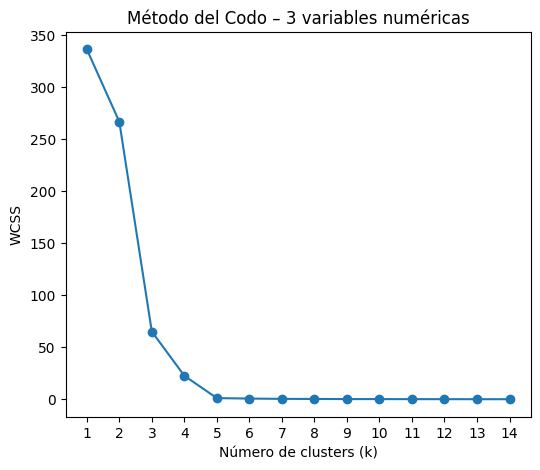

In [ ]:
WCSS_X2 = []
for k in range(1, 15):
    model = KMeans(n_clusters=k, init='k-means++', random_state=0)
    model.fit(x2_scaled)
    WCSS_X2.append(model.inertia_)

plt.figure(figsize=(6,5))
plt.plot(range(1, 15), WCSS_X2, marker='o')
plt.xticks(range(1, 15))
plt.xlabel("Número de clusters (k)")
plt.ylabel("WCSS")
plt.title("Método del Codo – 3 variables numéricas")
plt.show()

### 5.2.2 Aplicar K-Means y visualización 3D Matplotlib ### 
Aplicamos K-Means con k=4

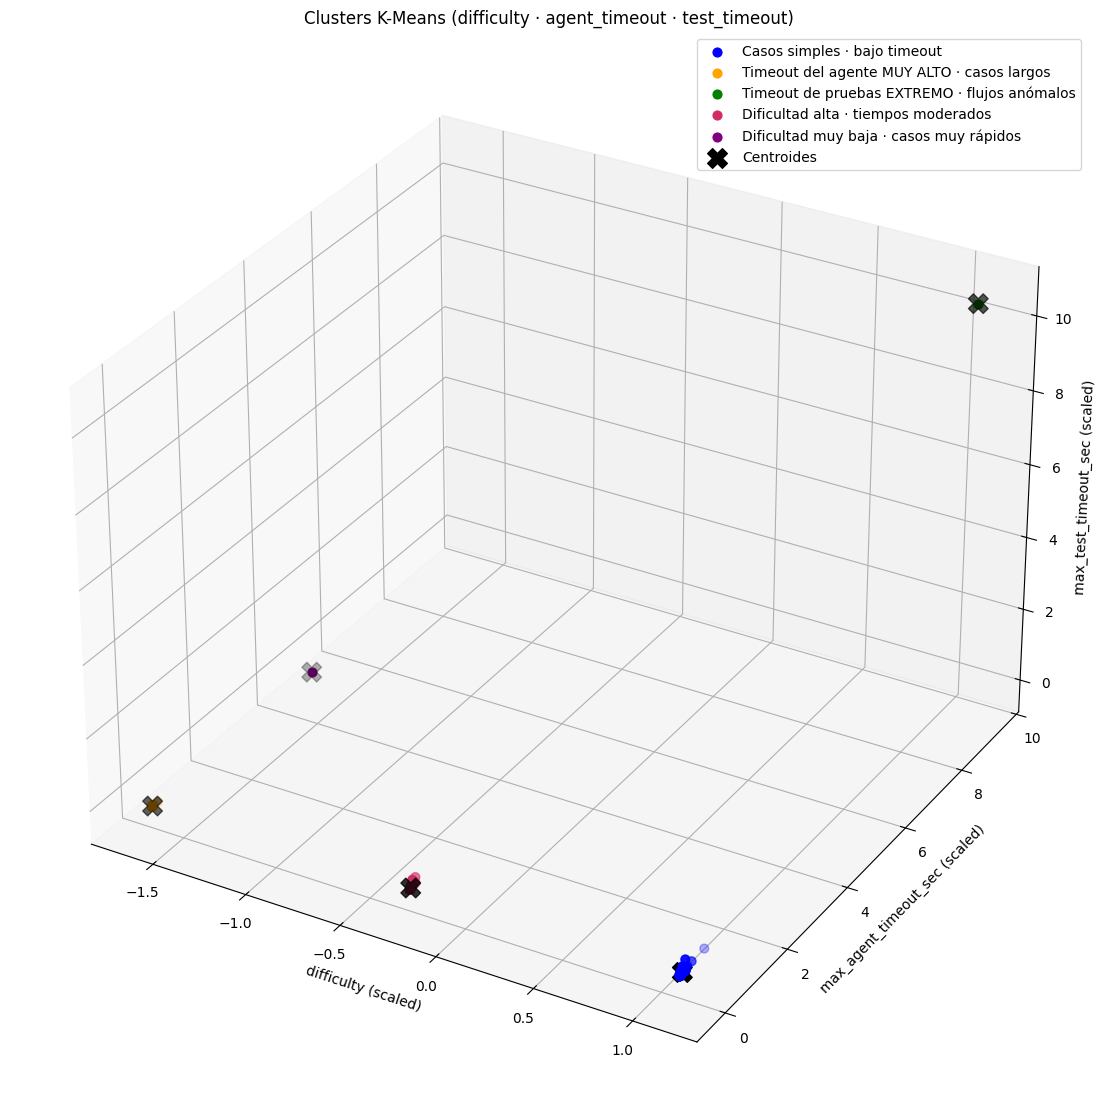

In [ ]:
clusters_opt = 5
model_x2 = KMeans(n_clusters=clusters_opt, init='k-means++', n_init=10, random_state=42)
y_clusters_x2 = model_x2.fit_predict(x2_scaled)

colors = ['blue', 'orange', 'green', '#D12B60', 'purple']

# Etiquetas interpretadas (puedes ajustarlas a tu contexto)
cluster_labels_x2 = [
    "Casos simples · bajo timeout",
    "Timeout del agente MUY ALTO · casos largos",
    "Timeout de pruebas EXTREMO · flujos anómalos",
    "Dificultad alta · tiempos moderados",
    "Dificultad muy baja · casos muy rápidos"
]

# Tomar centroides del modelo
centroids2 = model_x2.cluster_centers_


fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

for i in range(clusters_opt):
    ax.scatter(
        x2_scaled[y_clusters_x2 == i, 0],
        x2_scaled[y_clusters_x2 == i, 1],
        x2_scaled[y_clusters_x2 == i, 2],
        s=40,
        color=colors[i],
        label=cluster_labels_x2[i]
    )

# Centroides
ax.scatter(
    centroids2[:, 0],
    centroids2[:, 1],
    centroids2[:, 2],
    s=200,
    color='black',
    marker='X',
    label='Centroides'
)

ax.set_xlabel("difficulty (scaled)")
ax.set_ylabel("max_agent_timeout_sec (scaled)")
ax.set_zlabel("max_test_timeout_sec (scaled)")
ax.set_title("Clusters K-Means (difficulty · agent_timeout · test_timeout)")

ax.legend()
plt.show()


### 5.2.3 Gráfica Interactiva Ploty  ###

In [ ]:

centroids = model_x2.cluster_centers_

Scene = dict(
    xaxis=dict(title='difficulty (scaled)'),
    yaxis=dict(title='max_agent_timeout_sec (scaled)'),
    zaxis=dict(title='max_test_timeout_sec (scaled)')
)

labels_x2 = model_x2.labels_
trace_points = go.Scatter3d(
    x=x2_scaled[:, 0],  # difficulty
    y=x2_scaled[:, 1],  # max_agent_timeout_sec
    z=x2_scaled[:, 2],  # max_test_timeout_sec
    mode='markers',
    marker=dict(
        color=labels_x2,
        size=6,
        line=dict(color='black', width=0.5)
    ),
    name='Puntos'
)

trace_centroids = go.Scatter3d(
    x=centroids[:, 0],
    y=centroids[:, 1],
    z=centroids[:, 2],
    mode='markers',
    marker=dict(
        color='black',
        size=8,
        symbol='x',
        line=dict(color='white', width=2)
    ),
    name='Centroides'
)

layout = go.Layout(
    margin=dict(l=0, r=0),
    scene=Scene,
    height=700,
    width=700,
    title='Clusters K-Means – 3 variables (3D interactivo)'
)

fig = go.Figure(data=[trace_points, trace_centroids], layout=layout)
fig.show()


## 5.3 Conclusiones

# Conclusiones y Recomendaciones Empresariales por Cluster

El análisis de clustering permitió identificar grupos bien diferenciados de workloads según complejidad, tamaño, cantidad de archivos y tiempos de ejecución. Cada cluster revela comportamientos operativos importantes para optimizar infraestructura, costos y tiempos de respuesta.

---

## 1. Clusters basados en difficulty – n_files – archive_bytes

### **Cluster A — Workloads pequeños y homogéneos**

**Características:**

* Pocos archivos.
* Tamaño reducido (bytes bajos).
* Dificultad baja.

**Recomendación empresarial:**

* Mantener la configuración actual.
* Usarlos como referencia para detectar anomalías futuras.
* Pueden ejecutarse en infraestructura de bajo costo.

---

### **Cluster B — Artefactos grandes con tiempos moderados**

**Características:**

* n_files medio/alto.
* Tamaño del archivo grande.
* Dificultad moderada.

**Recomendación empresarial:**

* Optimizar caching y almacenamiento.
* Evaluar compresión o reducción del tamaño de artefactos.
* Asignar agentes con mejor I/O.

---

### **Cluster C — Casos anómalos por tamaño extremo**

**Características:**

* Tamaño extraordinariamente alto.
* n_files considerable.
* Dificultad variable.

**Recomendación empresarial:**

* Investigar manualmente.
* Revisar artefactos innecesariamente grandes.
* Implementar límites o políticas de tamaño máximo.

---

### **Cluster D — Workloads complejos pero estables**

**Características:**

* Alta dificultad.
* Tamaño medio.
* n_files medio.

**Recomendación empresarial:**

* Identificar scripts o procesos complejos que puedan dividirse.
* Aumentar caching.
* Monitorear uso de CPU y memoria para prevenir degradación.

---

### **Cluster E — Casos triviales y muy rápidos**

**Características:**

* Dificultad extremadamente baja.
* Mínimo tamaño y archivos.

**Recomendación empresarial:**

* Mantener como “smoke tests”.
* Ejecutarse en agentes más económicos.
* Útiles para test de disponibilidad del sistema.

---

## 2. Clusters basados en difficulty – max_agent_timeout_sec – max_test_timeout_sec

### **Cluster 1 — Casos simples con bajos tiempos**

**Características:**

* Difficulty baja.
* Tiempos pequeños en agent y test.

**Recomendación empresarial:**

* Mantener igual.
* Excelente para validación rápida.
* Usar como baseline operacional.

---

### **Cluster 2 — Timeout del agente muy alto**

**Características:**

* max_agent_timeout_sec extremadamente alto.
* Difficulty moderada.

**Recomendación empresarial:**

* Revisar cuellos de botella en agentes.
* Incrementar capacidad o paralelización.
* Investigar dependencias externas lentas.

---

### **Cluster 3 — Timeout extremo en pruebas**

**Características:**

* max_test_timeout_sec muy superior al resto.
* Aislado claramente en el eje Z (anomalía).

**Recomendación empresarial:**

* Revisar test suites lentos o con loops.
* Implementar early-stop.
* Paralelizar pruebas largas.
* Reducir tests redundantes.

---

### **Cluster 4 — Alta dificultad con tiempos moderados**

**Características:**

* Difficulty alta.
* Timeouts medios.

**Recomendación empresarial:**

* Mejorar caching y compilación incremental.
* Evaluar dividir el workload en etapas.
* Asignar agentes con más CPU.

---

### **Cluster 5 — Dificultad muy baja · tiempos mínimos**

**Características:**

* Difficulty muy baja.
* Timeouts casi cero.

**Recomendación empresarial:**

* Excelente rendimiento.
* Mantener en infra económica.
* Usarse para monitoreo de salud del sistema.

---

## Conclusión Global

Los clusters revelan tres áreas clave de acción empresarial:

### **1. Optimización de infraestructura**

* Reasignar agentes según complejidad del workload.
* Evitar uso excesivo de agentes de alta capacidad en casos triviales.

### **2. Reducción de tiempos y costos**

* Identificar workloads con timeouts elevados.
* Optimizar test suites y artefactos excesivamente grandes.

